# 20장 전이학습, 데이터 증식 - 뇌 사진 예제

## 데이터 증식 (Data Augmentation)
### * `ImageDataGenerator()`  
참고자료: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator

```python
    train_datagen = ImageDataGenerator(rescale=1./255,
                                    horizontal_flip=True,   
                                    width_shift_range=0.1,  
                                    height_shift_range=0.1, 
                                    rotation_range=5,
                                    shear_range=0.7,
                                    zoom_range=[0.9, 2.2],
                                    vertical_flip=True,
                                    fill_mode='nearest') 
```
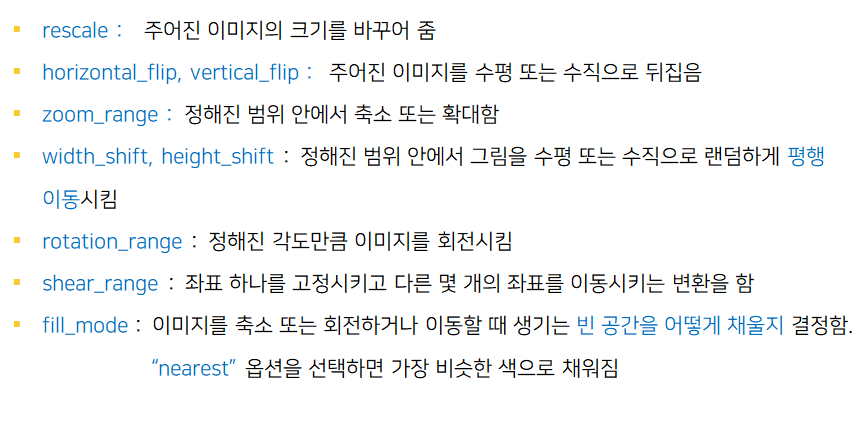

`ImageDataGenerator()`로 이미지를 변형시킬 범위 지정

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

train_datagen = ImageDataGenerator(rescale=1./255,
        # horizontal_flip=True,   # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
        width_shift_range=0.1,  # 전체 크기의 10% 범위에서 좌우로 이동합니다.
        height_shift_range=0.1, # 마찬가지로 위, 아래로 이동합니다.
        rotation_range=5,
        shear_range=0.7,
        zoom_range=[0.9, 2.2],
        vertical_flip=True,
        fill_mode='nearest')
train_datagen

`flow_from_directory()` 메서드로 이미지를 가져올 폴더를 지정하고, 생성할 이미지의 크기와 한번에 만들 이미지 개수(batch_size) 등을 정해준다.

In [13]:
path = 'data/data증식/'
batch_size = 5
train_generator = train_datagen.flow_from_directory(
       path,                     #+ #Z'고양이',   #학습셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=batch_size,    # 한 에포크당 몇장의 사진을 만들 것인가?
       class_mode='binary')

Found 20 images belonging to 2 classes.


반복문에서 train_generator가 실행될 때마다 batch개 만큼의 이미지 생성  
* 배치당 한줄에 이미지를 plot해 봄

batch=0


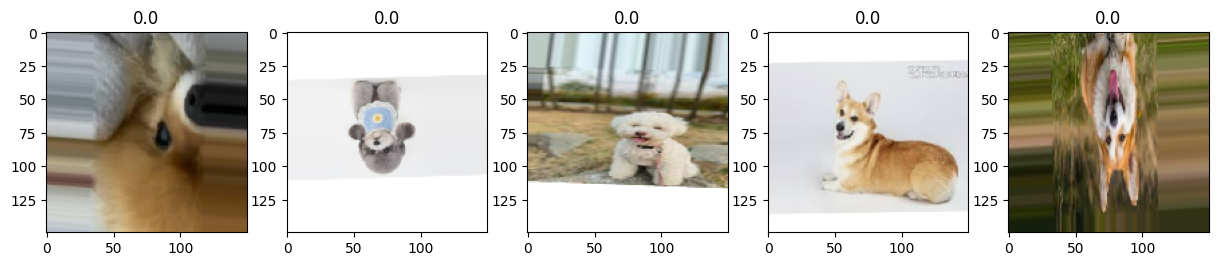

batch=1


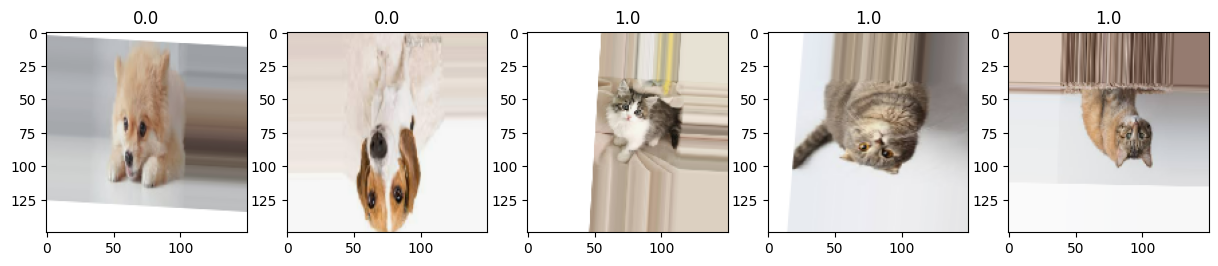

batch=2


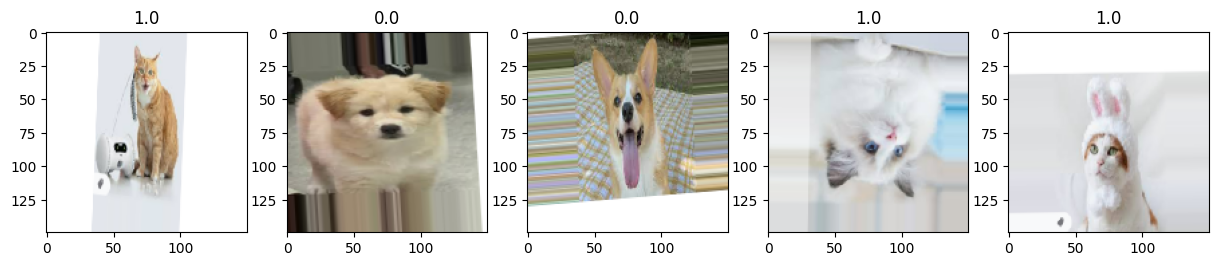

batch=3


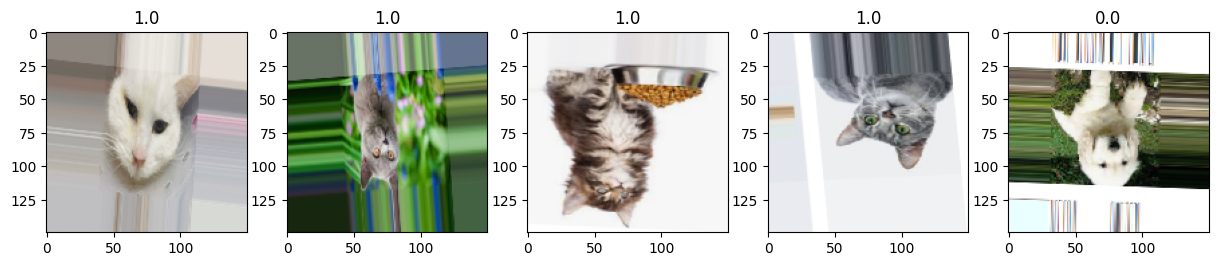

batch=4


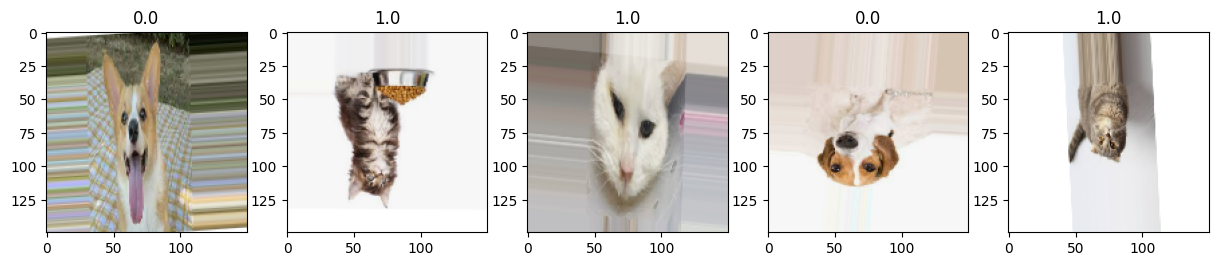

batch=5


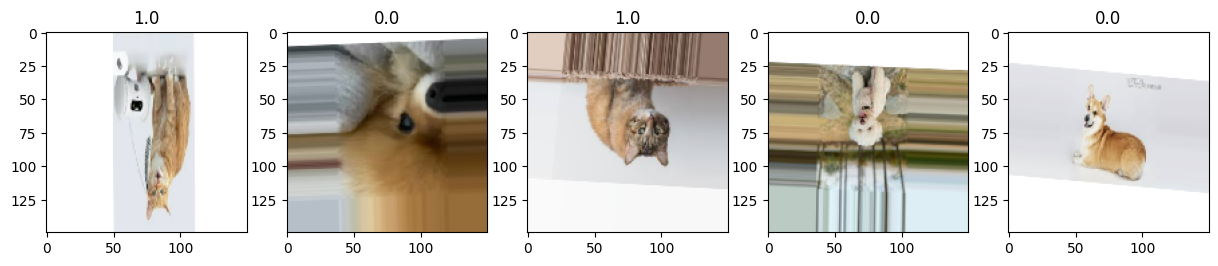

batch=6


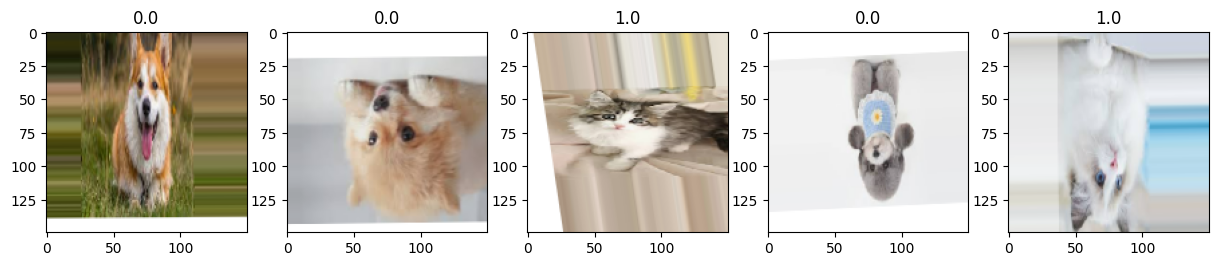

batch=7


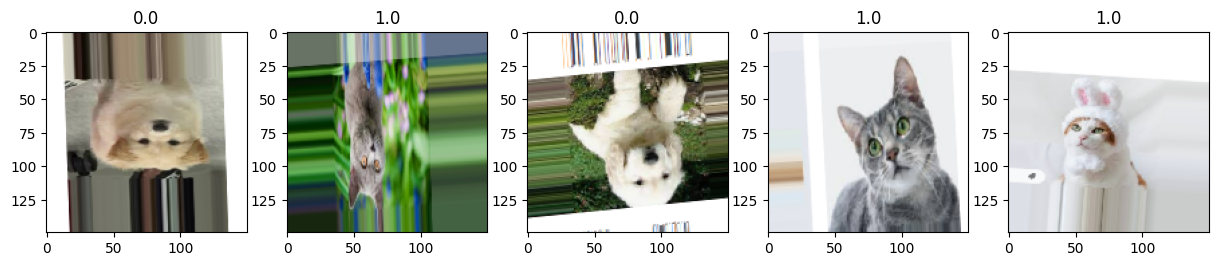

batch=8


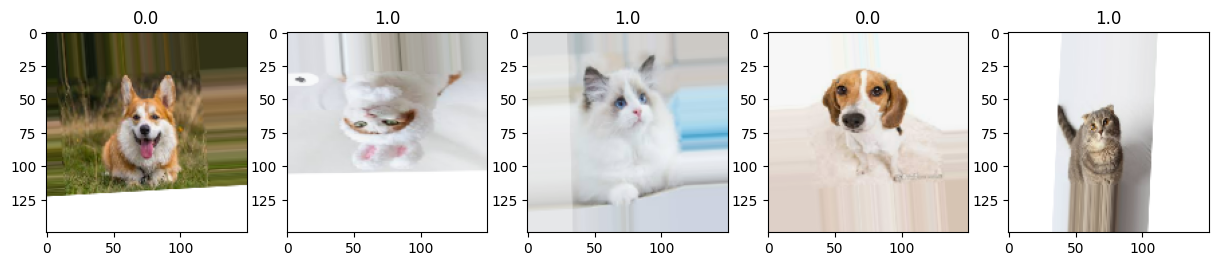

batch=9


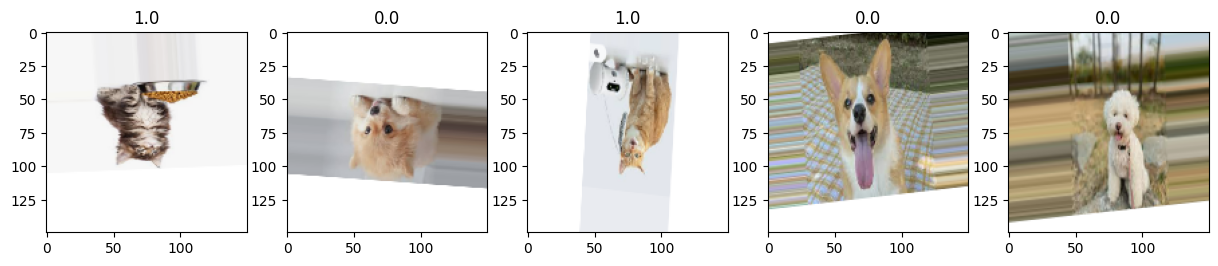

In [14]:
for i, (img, label) in enumerate(train_generator): # 하나의 batch만큼 generate됨
    print(f"batch={i}")
    plt.figure(figsize=(15, 15))
    for j in range(batch_size):  # 한 epoch에서 생성된 batch개의 이미지 show
        plt.subplot(1, batch_size, j+1)
        plt.title(label[j])
        plt.imshow(img[j])
        ### 생성된 이미지 저장하기
#         im = Image.fromarray((img[j]*255).round().astype(np.uint8))
#         im.save(path+f"new_img{i}-{j}-label{int(label[j])}.jpg")
    plt.show()
    if i >= 9:  # 0~9까지 총 10개 라인 (10x5=50개 data)
        break

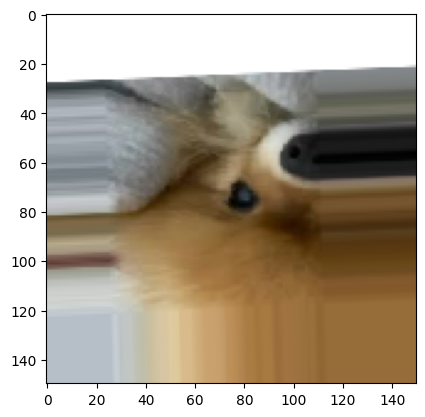

In [5]:
plt.imshow(img[0])

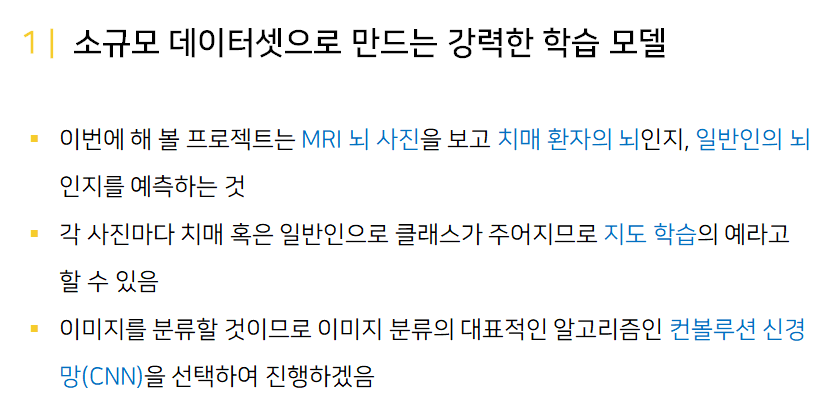

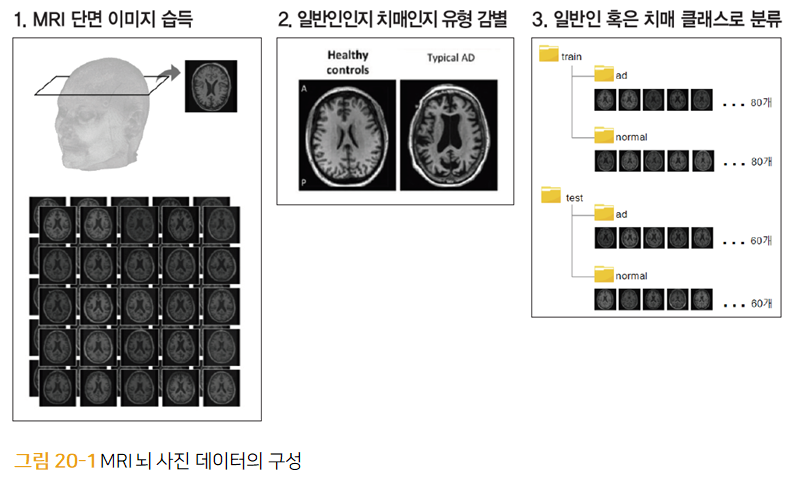

먼저 치매환자의 뇌 MRI를 확인하여 보자.

In [19]:
import glob
glob.glob("data/data증식/강아지/*.*")

['data/data증식/강아지\\강아지-1.png',
 'data/data증식/강아지\\강아지-2.png',
 'data/data증식/강아지\\강아지-3.png',
 'data/data증식/강아지\\강아지-4.png',
 'data/data증식/강아지\\강아지1.png',
 'data/data증식/강아지\\강아지2.png',
 'data/data증식/강아지\\강아지3.png',
 'data/data증식/강아지\\강아지4.png',
 'data/data증식/강아지\\강아지471.png',
 'data/data증식/강아지\\강아지5.png']

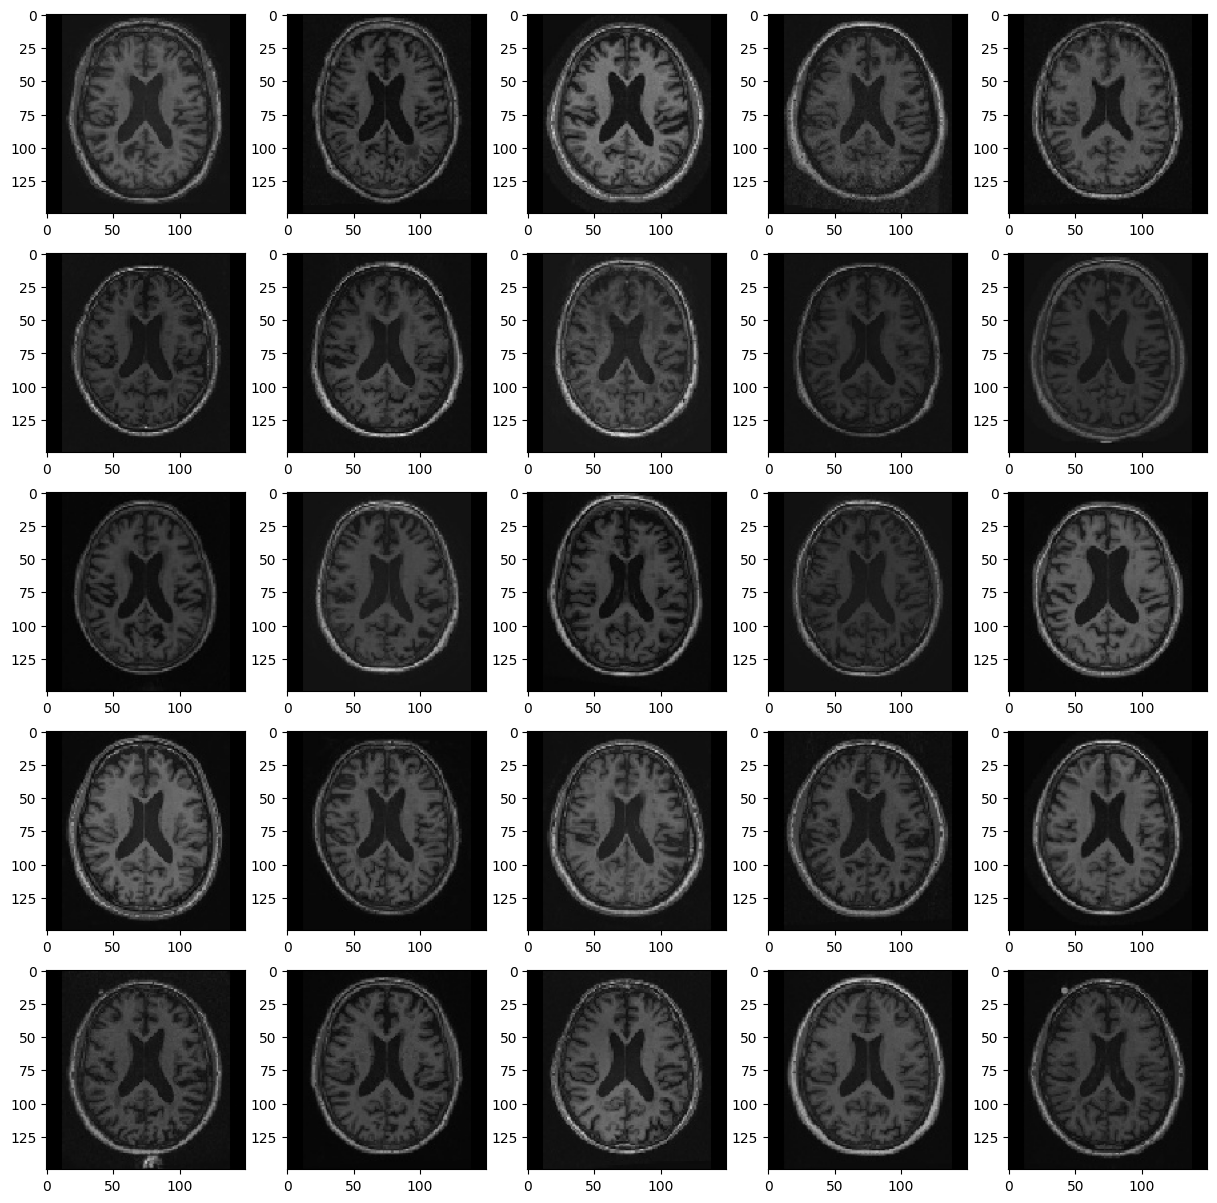

In [20]:
import glob
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 15))
img_paths = glob.glob('./data/brain_MRI_images/test/ad/*.jpg') # ad : 치매 환자
for i, img_path in enumerate(img_paths):
    if i > 24: break
    img = plt.imread(img_path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
plt.show()

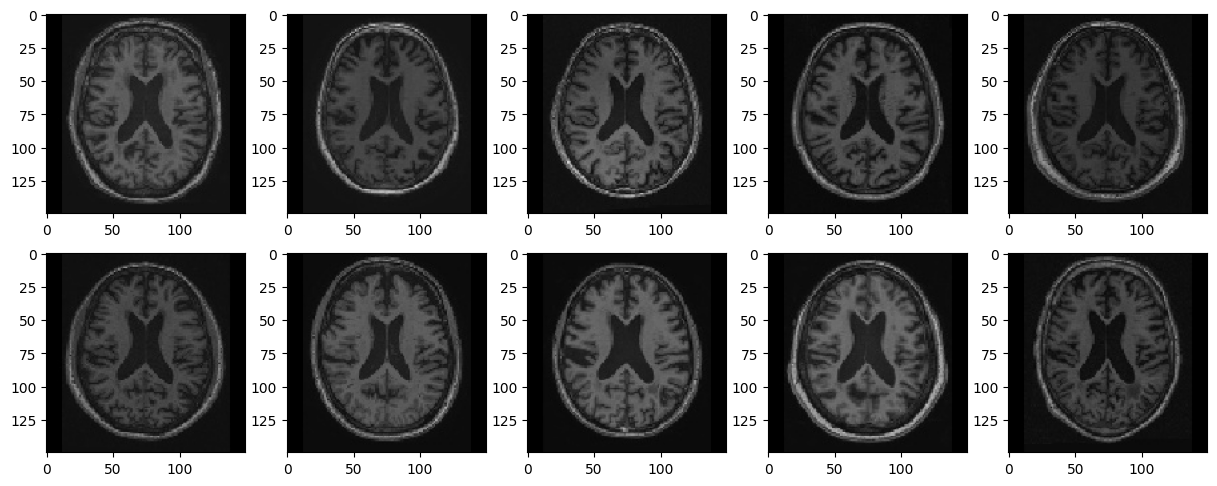

In [21]:
import matplotlib.pyplot as plt
## 10개의 ad 이미지를 화면에 표시해보기 (총 80개 데이터)
plt.figure(figsize=(15, 15))
for i in range(1, 11):
    img = plt.imread(f'./data/brain_MRI_images/test/ad/ad_test_{i}.jpg')
#     img = np.array(PIL.Image.open(f'C:/data/brain_MRI_images/test/ad/ad_test_{i}.jpg'))
    plt.subplot(5, 5, i)
    plt.imshow(img)
plt.show()

이제 일반인의 뇌 MRI를 확인해 보자.

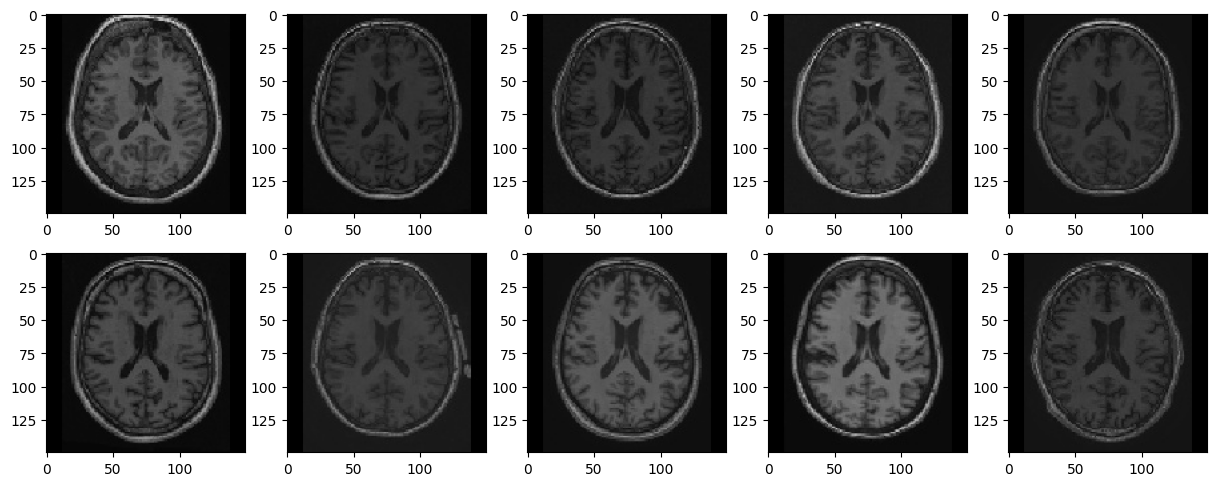

In [17]:
## 10개의 normal 이미지를 화면에 표시해보기 (총 80개 데이터)
plt.figure(figsize=(15, 15))
for i in range(1, 11):
    img = plt.imread(f'data/brain_MRI_images/test/normal/normal_test_{i}.jpg')
    plt.subplot(5, 5, i)
    plt.imshow(img)
plt.show()

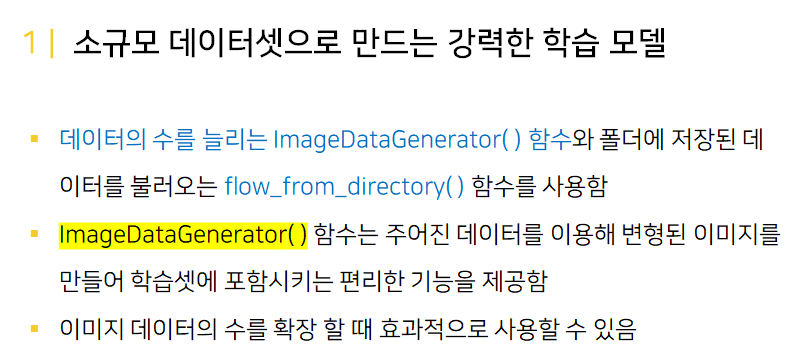

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers

import numpy as np
import matplotlib.pyplot as plt

#학습셋의 변형을 설정하는 부분입니다. 
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.1,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.1,   # 마찬가지로 위, 아래로 이동합니다.
                                  #rotation_range=5,        # 정해진 각도만큼 회전시킵니다.
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  #zoom_range=1.2,          # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  #fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )      

train_generator = train_datagen.flow_from_directory(
       './data/brain_MRI_images/train',   # 학습셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),            ## 모든 이미지는 150x150 크기로 resize
       batch_size=5,                      ## 한번에 5개 이미지 생성
       class_mode='binary')               ## 2진분류

# 테스트셋은 이미지 부풀리기 과정을 진행하지 않습니다.
test_datagen = ImageDataGenerator(rescale=1./255)  # 데이터 증강 없이 정규화 및 라벨링만 수행

test_generator = test_datagen.flow_from_directory(
       './data/brain_MRI_images/test',   # 테스트셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')


# 앞서 배운 CNN 모델을 만들어 적용해 보겠습니다.
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

Found 160 images belonging to 2 classes.


Found 120 images belonging to 2 classes.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 activation_5 (Activation)   (None, 148, 148, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 activation_6 (Activation)   (None, 72, 72, 32)        0         
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 36, 36, 32)       0         
 2D)         

In [25]:
#모델 실행의 옵션을 설정합니다. 
model.compile(loss='binary_crossentropy',
              optimizer='adam',
               #optimizer=optimizers.Adam(learning_rate=0.0002),
                metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

In [26]:
%%time
#모델을 실행합니다
# - 학습할 때, 총 160개의 데이터로 학습하면 1 epoch
#          - 하나의 step에는 5개 데이터가 입력됨 (batch_size=5)
#          - 1 epoch : 160 / 5 = 32 step
#          - 매 step 마다 다르게 변형된 사진이 공급됨
#          - 과적합을 어느정도 막아줌
history = model.fit(
       train_generator,            ### 데이터 대신 제너레이터로 학습데이터 제공
       epochs=100,
       validation_data=test_generator,    ## Validation Data 대신 test_generator로 제공
       validation_steps=10,               ## 테스트 데이터는 5개씩 10번 생성됨...
       callbacks=[early_stopping_callback])

Epoch 1/100
32/32 [==============================] - 13s 389ms/step - loss: 0.7031 - accuracy: 0.4625 - val_loss: 0.6916 - val_accuracy: 0.5400
Epoch 2/100
32/32 [==============================] - 10s 304ms/step - loss: 0.6938 - accuracy: 0.4938 - val_loss: 0.6838 - val_accuracy: 0.5600
Epoch 3/100
32/32 [==============================] - 11s 340ms/step - loss: 0.6902 - accuracy: 0.5437 - val_loss: 0.6725 - val_accuracy: 0.5800
Epoch 4/100
32/32 [==============================] - 15s 461ms/step - loss: 0.6931 - accuracy: 0.5875 - val_loss: 0.6772 - val_accuracy: 0.8000
Epoch 5/100
32/32 [==============================] - 14s 420ms/step - loss: 0.6708 - accuracy: 0.6313 - val_loss: 0.6604 - val_accuracy: 0.5200
Epoch 6/100
32/32 [==============================] - 21s 669ms/step - loss: 0.6553 - accuracy: 0.5437 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 7/100
32/32 [==============================] - 25s 784ms/step - loss: 0.6727 - accuracy: 0.6250 - val_loss: 0.5603 - val_accuracy:

In [ ]:
df_history[['loss', 'val_loss']].plot()

In [ ]:
import pandas as pd
df_history = pd.DataFrame(history.history)
df_history.plot()

#### 모델 검증

In [ ]:
model.summary()

In [ ]:
## input data dimension = (150, 150, 3)
# 치매환자 뇌 테스트
from PIL import Image
path = './data/brain_MRI_images/'
test_img = Image.open(path + 'test/ad/ad_test_1.jpg')
test_img

In [ ]:
## predict하려는 이미지는 크기가 150x150x3 의 형태가 되어야함 (학습 데이터와 일치!)

In [ ]:
# (1) Resize
test_img = Image.open(path + 'test/ad/ad_test_17.jpg')
test_img_array = np.array(test_img)
print(test_img_array.shape)
model.predict(test_img_array[np.newaxis,:, :, :])

In [ ]:
# (2) 1/255. 으로 정규화
test_img_array_2 = test_img_array /255.
test_img_array.max(), test_img_array_2.max()

In [ ]:
# (3) shape를 (N, 150, 150, 3)의 형태이어야 함
test_img_array_3 = test_img_array_2[np.newaxis, :, : ,:]
test_img_array_3.shape, test_img_array_2.shape

In [ ]:
# 학습데이터와 동일하게 가공된 이미지로 예측
model.predict(test_img_array_3)

In [ ]:

test_img_array = test_img_array[np.newaxis,:, :, :].shape

In [ ]:
model.predict(test_img_array[np.newaxis,:, :, :]).round()[0, 0]

In [ ]:
##################################################
#  치매환자의 MRI(0) 검증
##################################################
right_cnt = 0
for i in range(1, 61):
    test_img = Image.open(path + f'test/ad/ad_test_{i}.jpg')
    test_img_array = np.array(test_img) / 255.
#     print(model.predict(test_img_array[np.newaxis,:, :, :]).round())
    predicted = model.predict(test_img_array[np.newaxis,:, :, :], verbose=0).round()[0, 0]
    print(f"({i}) {predicted}")
    if predicted == 0:  # 치매환자의 뇌
        right_cnt += 1
print(f"정답 수: {right_cnt},  Accuracy: {right_cnt / i}, Total sample: {i}")

In [ ]:
##################################################
#  일반인의 MRI(1) 검증
##################################################
right_cnt = 0
for i in range(1, 61):
    test_img = Image.open(path + f'test/normal/normal_test_{i}.jpg')
    test_img_array = np.array(test_img) / 255.
    predicted = model.predict(test_img_array[np.newaxis,:, :, :], verbose=0).round()[0, 0]
    print(f"({i}) {predicted}")
    if predicted == 1: ## 일반인의 뇌
        right_cnt += 1
print(f"정답 수: {right_cnt},  Accuracy: {right_cnt / i}, Total sample: {i}")

## 전이학습

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Input, models, layers, optimizers, metrics
from tensorflow.keras.layers import Dense, Flatten, Activation, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# 학습셋의 변형을 설정하는 부분입니다. 
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.1,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.1,   # 마찬가지로 위, 아래로 이동합니다.
                                  #rotation_range=5,        # 정해진 각도만큼 회전시킵니다.
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  #zoom_range=1.2,          # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  #fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )      


train_generator = train_datagen.flow_from_directory(
       path + '/train',
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

# 테스트셋의 정규화를 설정합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
       path + '/test',
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

# VGG16 모델을 불러옵니다.
# include_top=False : 원래 ImageNet 분류용 FC층(fully connected layer) 포함 안함 (특징 추출용)
# transfer_mode.trainable=False : 사전 학습된 가중치를 고정 (freeze), 훈련 중 업데이트 안함
# 
# transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model.trainable = False
transfer_model.summary()

# 우리의 모델을 설정합니다.
finetune_model = models.Sequential()
finetune_model.add(transfer_model)
finetune_model.add(Flatten())
finetune_model.add(Dense(64))
finetune_model.add(Activation('relu'))
finetune_model.add(Dropout(0.5))
finetune_model.add(Dense(1))
finetune_model.add(Activation('sigmoid'))
finetune_model.summary()

In [ ]:
# 모델의 실행 옵션을 설정합니다. 
finetune_model.compile(loss='binary_crossentropy',
                       optimizer=optimizers.Adam(learning_rate=0.0002), 
                       metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
%%time
# 모델을 실행합니다.
history = finetune_model.fit(
       train_generator,
       epochs=20,
       validation_data=test_generator,
       validation_steps=10, 
       callbacks=[early_stopping_callback])

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()